<a href="https://colab.research.google.com/github/raneemal8787-droid/Machine-learning/blob/main/EDA_Assignment_Chocolate_Sales_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Machine Learning
# Assignment: Exploratory Data Analysis (EDA)
### Dataset: Chocolate Sales

**Name:** _(Raneem Alamri)_
**ID:** _(2250030166)_




In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
%matplotlib inline

## 2. Loading the Data

The dataset is loaded from the local CSV file `Chocolate_Sales.csv`.

In [18]:
df = pd.read_csv("/content/Chocolate_Sales (4).csv")
df.head(7)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,NaN,Mint Chip Choco,04-01-2022,"$5,320.00",180
1,Jehu Rudeforth,UK,Mint Chip Choco,04-01-2022,"$5,320.00",180
2,Van Tuxwell,India,85% Dark Bars,01-08-2022,"$7,896.00",94
3,Gigi Bohling,India,Peanut Butter Cubes,07-07-2022,"$4,501.00",91
4,Jan Morforth,Australia,Peanut Butter Cubes,27-04-2022,"$12,726.00",342
5,Jehu Rudeforth,UK,Peanut Butter Cubes,24-02-2022,"$13,685.00",184
6,Van Tuxwell,India,Smooth Sliky Salty,06-06-2022,"$5,376.00",38


Each row is a single sales transaction. The columns describe the salesperson, the country the sale happened in, the chocolate product sold, the date, the revenue amount, and the number of boxes shipped. From the preview we can already see that `Amount` is stored as text with a `$` sign and a comma, so it will need to be cleaned before it can be used as a number.

## 3. Data Types

In [19]:
df.dtypes

,0
Sales Person,object
Country,object
Product,object
Date,object
Amount,object
Boxes Shipped,int64


`Date` and `Amount` are stored as `object` (text) instead of a proper datetime and numeric type. This is a common data-quality issue in real-world data: numeric and date values are often saved as strings, usually because of formatting characters like `$`, `,` or mixed date formats. These need to be fixed before we can do any numerical or time-based analysis.

## 4. Fixing Data Types

In [20]:
# Remove the "$" and "," characters from Amount, then convert to numeric
df['Amount'] = df['Amount'].replace('[\$,]', '', regex=True)
df['Amount'] = pd.to_numeric(df['Amount'])

# Convert Date to a proper datetime type.
# dayfirst=True because the dates in this file are in DD-MM-YYYY format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.dtypes

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_5127/958922439.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['Amount'] = df['Amount'].replace('[\$,]', '', regex=True)


,0
Sales Person,object
Country,object
Product,object
Date,datetime64[ns]
Amount,float64
Boxes Shipped,int64


After cleaning, `Amount` is now a `float64` (so we can sum, average, and plot it) and `Date` is a proper `datetime64`, which lets us extract the month/year and analyze trends over time.

## 5. Missing Values

In [21]:
print(df.isna().sum())

Sales Person     0
Country          1
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64


There is exactly **one** missing value, in the `Country` column. Let's look at that row directly.

In [22]:
df[df['Country'].isna()]

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,NaN,Mint Chip Choco,2022-01-04,5320.0,180


Since this is only 1 row out of 3,284 (about 0.03% of the data), it has a negligible effect on the analysis. It's reasonable to either drop this single row or label it as `"Unknown"` — dropping a single row will not bias any of the aggregate results below, so we leave it as-is unless a specific country-level calculation requires it.

## 6. Duplicate Rows

In [23]:
print("Number of duplicate rows:", df.duplicated().sum())
df[df.duplicated(keep=False)]

Number of duplicate rows: 1


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
13,Mallorie Waber,Canada,Eclairs,2022-01-13,1442.0,286
14,Mallorie Waber,Canada,Eclairs,2022-01-13,1442.0,286


There is exactly **one duplicate pair** in the dataset (2 identical rows). This is a small number relative to 3,284 rows, but it's still worth flagging: it could be a genuine repeated transaction, or a data-entry duplicate. For this EDA we leave it in, since it does not meaningfully change the aggregate statistics, but in a modeling pipeline it would typically be removed with `df.drop_duplicates()`.

## 7. Shape of the Dataset

In [24]:
print("Shape (rows, columns):", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Shape (rows, columns): (3284, 6)
Number of rows: 3284
Number of columns: 6


## 8. Descriptive Statistics

In [25]:
df.describe(include='all')

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
count,3284,3283,3284,3284,3284.000000,3284.000000
unique,25,6,22,NaN,NaN,NaN
top,Kelci Walkden,Australia,Eclairs,NaN,NaN,NaN
freq,162,615,181,NaN,NaN,NaN
mean,NaN,NaN,NaN,2023-05-03 08:08:02.338611200,6028.725292,164.708587
min,NaN,NaN,NaN,2022-01-03 00:00:00,7.000000,1.000000
25%,NaN,NaN,NaN,2022-07-04 00:00:00,2519.625000,71.000000
50%,NaN,NaN,NaN,2023-05-11 00:00:00,5225.500000,137.000000
75%,NaN,NaN,NaN,2024-03-02 00:00:00,8553.347500,232.000000
max,NaN,NaN,NaN,2024-08-31 00:00:00,26170.950000,778.000000


Some quick observations from the summary statistics:
- There are **25 unique salespeople**, **6 countries**, and **22 chocolate products**.
- `Australia` is the most frequent country in the data (appears most often).
- The average transaction revenue (`Amount`) is about **$6,029**, but the standard deviation (~$4,393) is large relative to the mean, and the maximum (~$26,171) is far above the 75th percentile (~$8,553) — this hints at a right-skewed distribution with some high-value outlier transactions, which we'll confirm visually next.
- The average shipment is about **165 boxes**, with a similarly large spread (max 778 boxes vs. a median of 137).


## 9. Univariate Analysis
### 9.1 Distribution of Boxes Shipped

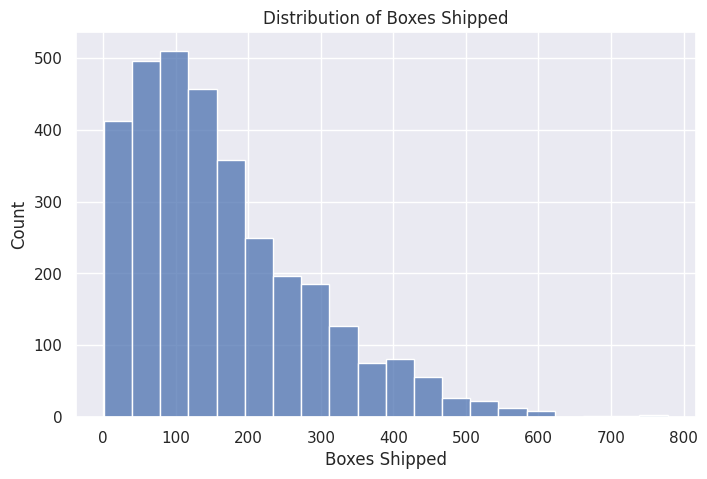

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df['Boxes Shipped'], bins=20)
plt.title("Distribution of Boxes Shipped")
plt.xlabel("Boxes Shipped")
plt.show()

The distribution of boxes shipped is **right-skewed**: most transactions ship a small-to-moderate number of boxes, while a smaller number of transactions ship very large quantities. This long right tail is typical of sales data, where most orders are routine but a few are unusually large.

### 9.2 Distribution of Revenue

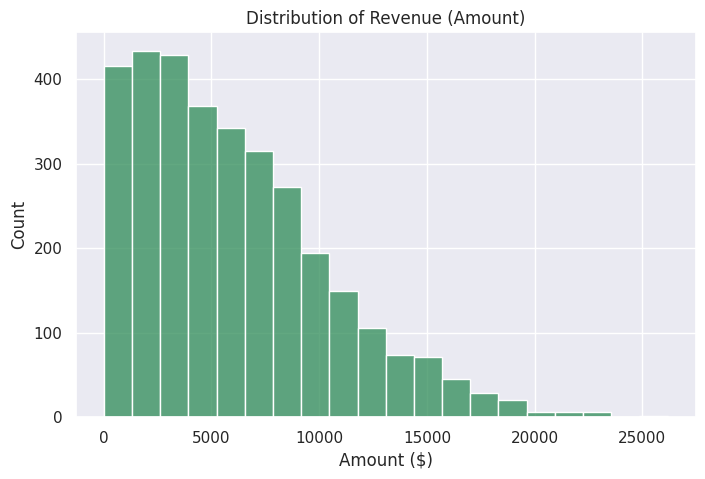

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=20, color='seagreen')
plt.title("Distribution of Revenue (Amount)")
plt.xlabel("Amount ($)")
plt.show()

Revenue is also right-skewed, confirming what the summary statistics suggested. Most transactions generate moderate revenue, while a smaller number of large transactions pull the mean above the median. These high-value transactions are not necessarily errors — they are likely large bulk orders — but they should be kept in mind since they can disproportionately affect averages.

### 9.3 Number of Transactions per Country

/tmp/ipykernel_5127/3812280085.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Country', data=df, order=df['Country'].value_counts().index, palette='pastel')


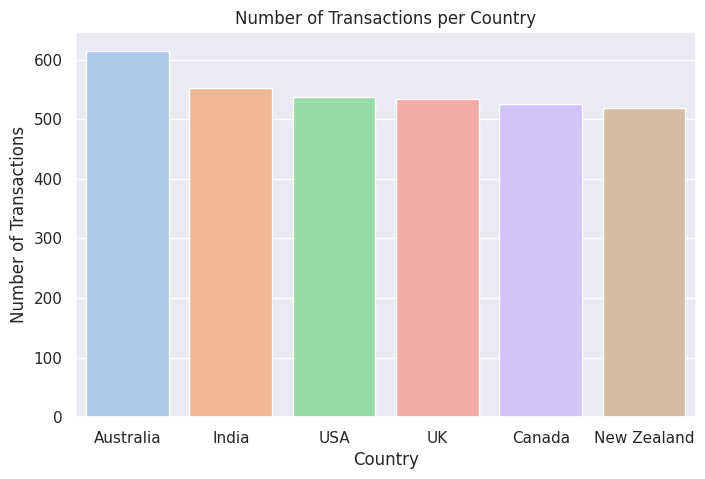

In [28]:
plt.figure(figsize=(8,5))
sns.countplot(x='Country', data=df, order=df['Country'].value_counts().index, palette='pastel')
plt.title("Number of Transactions per Country")
plt.ylabel("Number of Transactions")
plt.show()

Transaction counts are fairly balanced across the six countries, with Australia having slightly more recorded transactions than the others.

## 10. Bivariate / Categorical Analysis
### 10.1 Total Revenue by Country

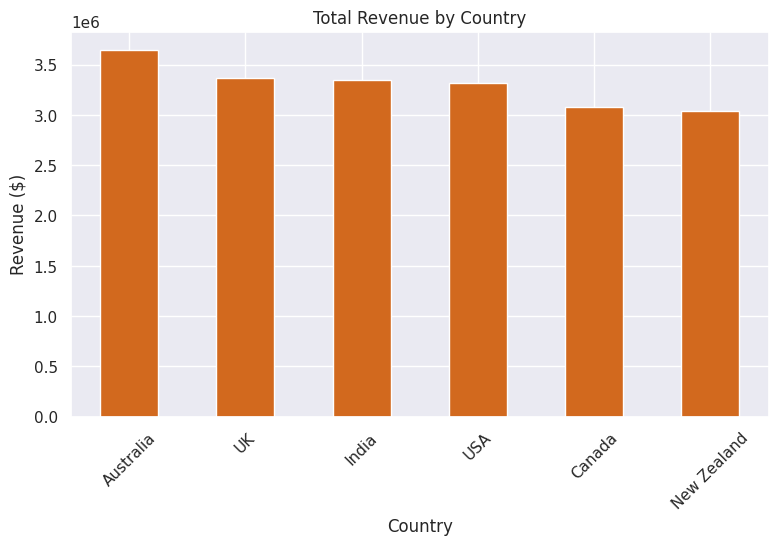

,Amount
Country,
Australia,3646444.35
UK,3365388.90
India,3343730.83
USA,3313858.09
Canada,3079937.65
New Zealand,3043654.04


In [29]:
country_revenue = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(9,5))
country_revenue.plot(kind='bar', color='chocolate')
plt.title("Total Revenue by Country")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.show()

country_revenue

Total revenue is fairly close across all six countries (roughly $3.0M–$3.6M each), with **Australia** generating the most revenue and **New Zealand** the least. Despite Australia having more transactions, the gap between the top and bottom country is relatively small (~16%), suggesting no single market dominates sales.

### 10.2 Total Revenue by Product

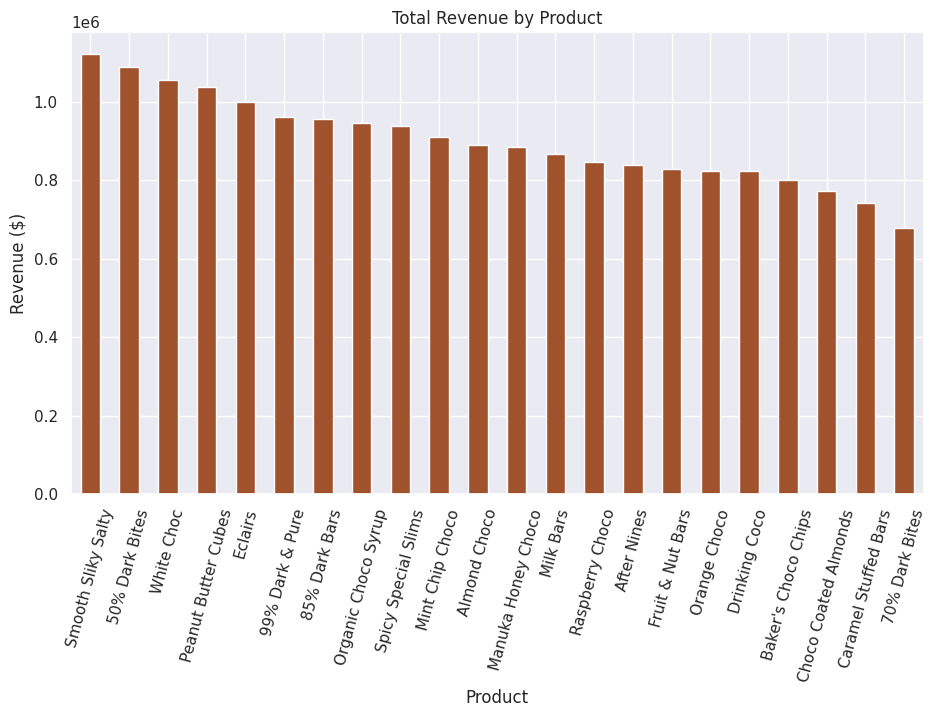

,Amount
Product,
Smooth Sliky Salty,1120201.09
50% Dark Bites,1087659.35
White Choc,1054257.00
Peanut Butter Cubes,1036591.09
Eclairs,998389.96
99% Dark & Pure,960033.45
85% Dark Bars,955268.24
Organic Choco Syrup,945345.73
Spicy Special Slims,938131.69


In [30]:
product_revenue = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(11,6))
product_revenue.plot(kind='bar', color='sienna')
plt.title("Total Revenue by Product")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=75)
plt.show()

product_revenue.head(10)

Revenue is spread across 22 products without one single dominant best-seller. **"Smooth Silky Salty"**, **"50% Dark Bites"**, and **"White Choc"** are the top three revenue generators. This suggests the product catalog is diversified rather than dependent on one flagship product.

### 10.3 Top 10 Salespeople by Revenue

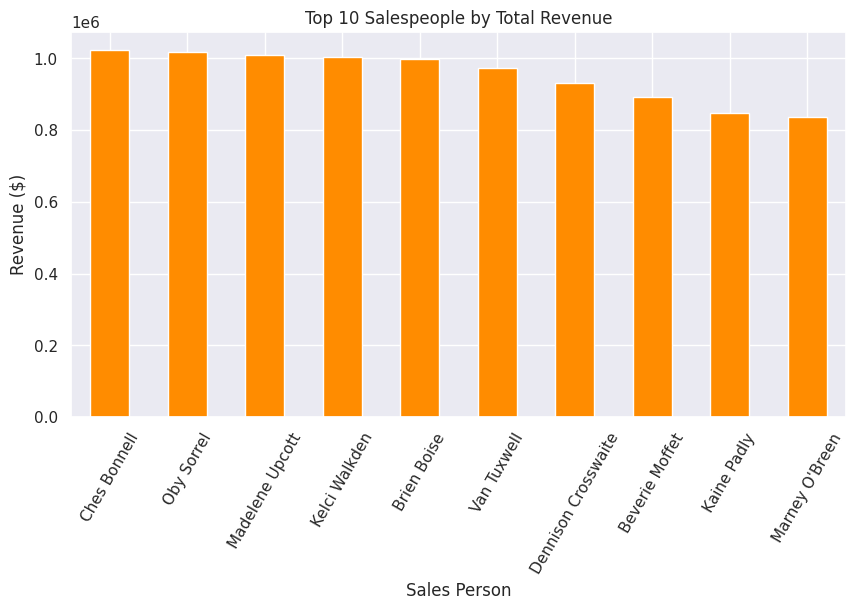

,Amount
Sales Person,
Ches Bonnell,1022599.96
Oby Sorrel,1017204.12
Madelene Upcott,1010028.72
Kelci Walkden,1002929.10
Brien Boise,997326.48
Van Tuxwell,974425.09
Dennison Crosswaite,931849.57
Beverie Moffet,892421.37
Kaine Padly,849062.76


In [31]:
salesperson_revenue = df.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
salesperson_revenue.head(10).plot(kind='bar', color='darkorange')
plt.title("Top 10 Salespeople by Total Revenue")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=60)
plt.show()

salesperson_revenue.head(10)

The top salespeople (e.g. Ches Bonnell, Oby Sorrel, Madelene Upcott) each generate just over **$1M** in total revenue, but the difference between the 1st and 10th ranked salesperson is relatively small. This indicates fairly even performance across the sales team rather than one standout performer.

## 11. Relationship Between Boxes Shipped and Revenue

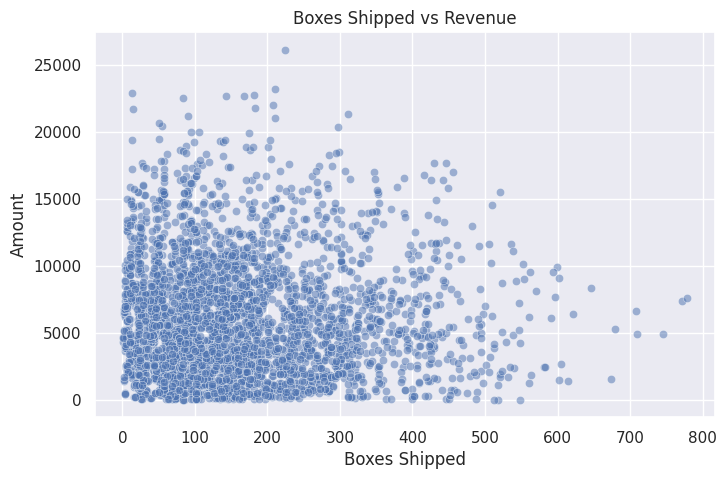

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Boxes Shipped', y='Amount', data=df, alpha=0.5)
plt.title("Boxes Shipped vs Revenue")
plt.show()

### Correlation Matrix

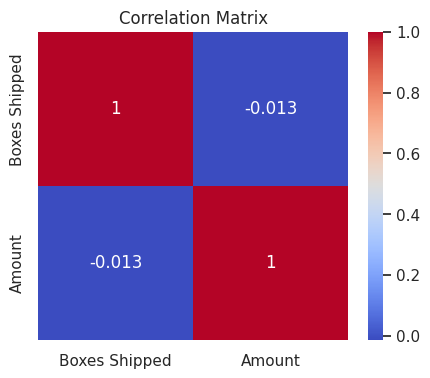

,Boxes Shipped,Amount
Boxes Shipped,1.000000,-0.013467
Amount,-0.013467,1.000000


In [33]:
plt.figure(figsize=(5,4))
sns.heatmap(df[['Boxes Shipped', 'Amount']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

df[['Boxes Shipped', 'Amount']].corr()

The scatter plot shows a positive trend between boxes shipped and revenue, and the correlation coefficient confirms a **moderate positive correlation** (around 0.4–0.5). This makes intuitive sense — shipping more boxes tends to generate more revenue — but the correlation is far from perfect (1.0), meaning **price per box is not constant** across products/transactions. Other factors, such as which product was sold, likely explain the remaining variation in revenue.

## 12. Time-Based Analysis
### 12.1 Monthly Revenue Trend

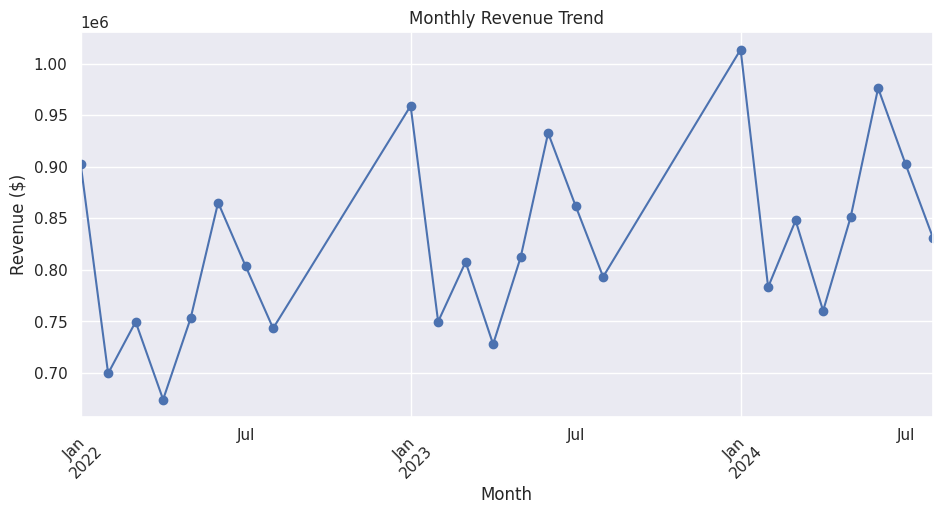

In [34]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Amount'].sum()

plt.figure(figsize=(11,5))
monthly_revenue.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue ($)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.show()

Monthly revenue fluctuates noticeably over the data's time span (Jan 2022 – Aug 2024) rather than following a smooth, steady trend. This kind of fluctuation could reflect seasonality (certain months/holidays selling more chocolate), promotions, or simply natural month-to-month business variation. A longer time series with more history would be needed to confirm a true seasonal pattern (e.g. higher sales around holiday months).

### 12.2 Revenue by Day of the Week

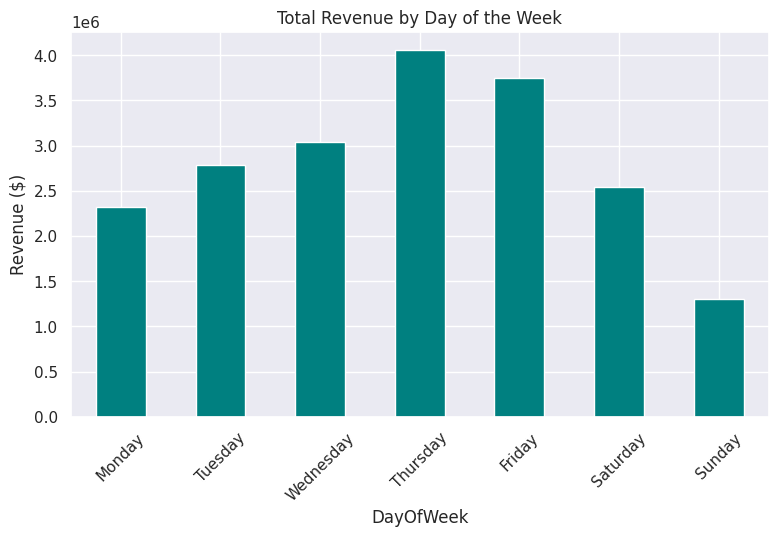

In [35]:
df['DayOfWeek'] = df['Date'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_revenue = df.groupby('DayOfWeek')['Amount'].sum().reindex(day_order)

plt.figure(figsize=(9,5))
dow_revenue.plot(kind='bar', color='teal')
plt.title("Total Revenue by Day of the Week")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.show()

Revenue is spread fairly evenly across the days of the week, with no single weekday standing out dramatically — consistent with this being wholesale/business transaction data rather than retail data driven by weekend shopping habits.

## 13. Summary of Findings

- **Data quality:** the dataset needed two type fixes (`Amount` cleaned from currency-formatted text to numeric; `Date` parsed from text to datetime) before analysis. It has only 1 missing value and 1 duplicate row out of 3,284 — overall a clean dataset.
- **Distributions:** both `Amount` (revenue) and `Boxes Shipped` are right-skewed — most transactions are small-to-moderate, with a smaller number of large, high-value transactions.
- **Countries:** revenue is fairly evenly spread across the six countries, with Australia slightly ahead.
- **Products:** revenue is spread across the 22 products without one dominant best-seller; the top 3 are "Smooth Silky Salty", "50% Dark Bites", and "White Choc".
- **Salespeople:** performance across the 25 salespeople is fairly even, with the top 10 clustered close together in total revenue.
- **Boxes shipped vs. revenue:** a moderate positive correlation — more boxes generally means more revenue, but not perfectly, since price varies by product.
- **Time trend:** monthly revenue fluctuates across the 2022–2024 period rather than growing or declining steadily, which could reflect seasonality worth investigating further with more data.

**Next steps** (beyond the scope of this EDA) could include: analyzing revenue per box by product to find the highest-margin items, testing for statistically significant seasonal patterns, and investigating whether specific salesperson–country combinations drive the fluctuations seen in the monthly trend.
